In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the Online Retail dataset
df = pd.read_excel("/content/Online Retail.xlsx")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (541909, 8)


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5268


In [9]:
# Remove duplicate rows
df = df.drop_duplicates()
print("Duplicates removed successfully!")
print("New shape:", df.shape)

Duplicates removed successfully!
New shape: (536641, 8)


In [10]:
# Check rows with missing CustomerID and Description
print("Missing CustomerID rows:", df["CustomerID"].isnull().sum())
print("Missing Description rows:", df["Description"].isnull().sum())

Missing CustomerID rows: 135037
Missing Description rows: 1454


In [12]:
# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])
print("Missing CustomerID rows removed!")
print("New shape:", df.shape)

Missing CustomerID rows removed!
New shape: (401604, 8)


In [14]:
# Remove rows with missing Description
df = df.dropna(subset=["Description"])
print("Missing Description rows removed!")
print("New shape:", df.shape)

Missing Description rows removed!
New shape: (401604, 8)


In [15]:
# Calculate total sales for each transaction
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]
print("Total Sales calculated successfully!")
df.head()

Total Sales calculated successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [16]:
# Calculate total revenue
total_revenue = df["TotalSales"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 8278519.4240000015


In [17]:
# Count unique customers
unique_customers = df["CustomerID"].nunique()
print("Number of Unique Customers:", unique_customers)

Number of Unique Customers: 4372


In [18]:
# Count unique products
unique_products = df["StockCode"].nunique()
print("Number of Unique Products:", unique_products)

Number of Unique Products: 3684


In [19]:
# Find top-selling products by quantity
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print("Top 10 Best-Selling Products:")
print(top_products)

Top 10 Best-Selling Products:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53119
JUMBO BAG RED RETROSPOT               44963
ASSORTED COLOUR BIRD ORNAMENT         35215
WHITE HANGING HEART T-LIGHT HOLDER    34128
PACK OF 72 RETROSPOT CAKE CASES       33386
POPCORN HOLDER                        30492
RABBIT NIGHT LIGHT                    27045
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25305
PACK OF 60 PINK PAISLEY CAKE CASES    24129
Name: Quantity, dtype: int64


In [20]:
# Create a date column
df["Date"] = df["InvoiceDate"].dt.date
# Calculate daily sales
daily_sales = df.groupby("Date")["TotalSales"].sum()
print("Daily Sales:")
print(daily_sales.head())

Daily Sales:
Date
2010-12-01    45867.26
2010-12-02    45656.47
2010-12-03    22553.38
2010-12-05    30970.28
2010-12-06    30258.77
Name: TotalSales, dtype: float64


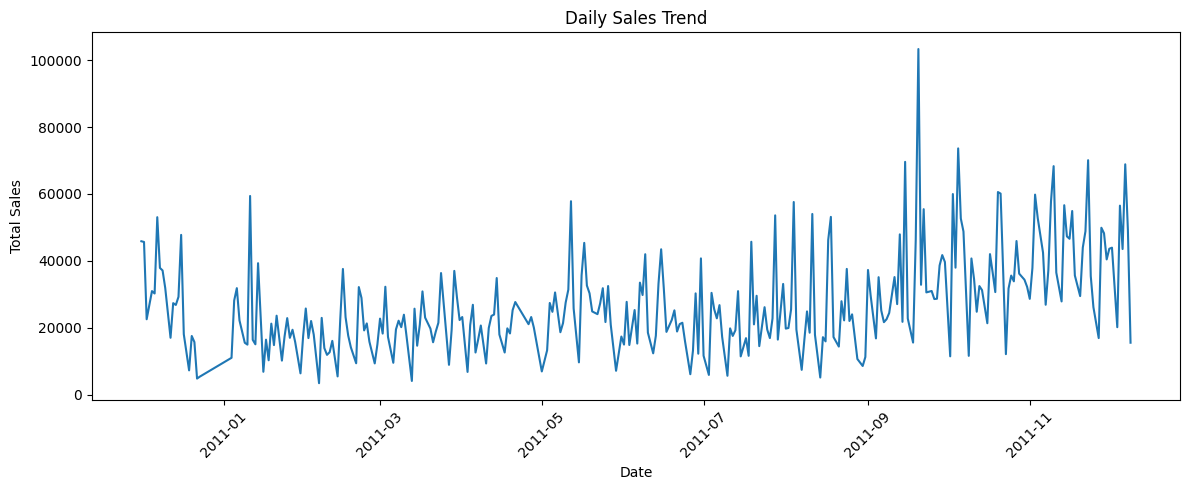

In [21]:
# Visualize daily sales trend
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Calculate monthly sales
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly_sales = df.groupby("Month")["TotalSales"].sum()
print("Monthly Sales:")
print(monthly_sales)

Monthly Sales:
Month
2010-12     552372.860
2011-01     473731.900
2011-02     435534.070
2011-03     578576.210
2011-04     425222.671
2011-05     647011.670
2011-06     606862.520
2011-07     573112.321
2011-08     615078.090
2011-09     929356.232
2011-10     973306.380
2011-11    1126815.070
2011-12     341539.430
Freq: M, Name: TotalSales, dtype: float64


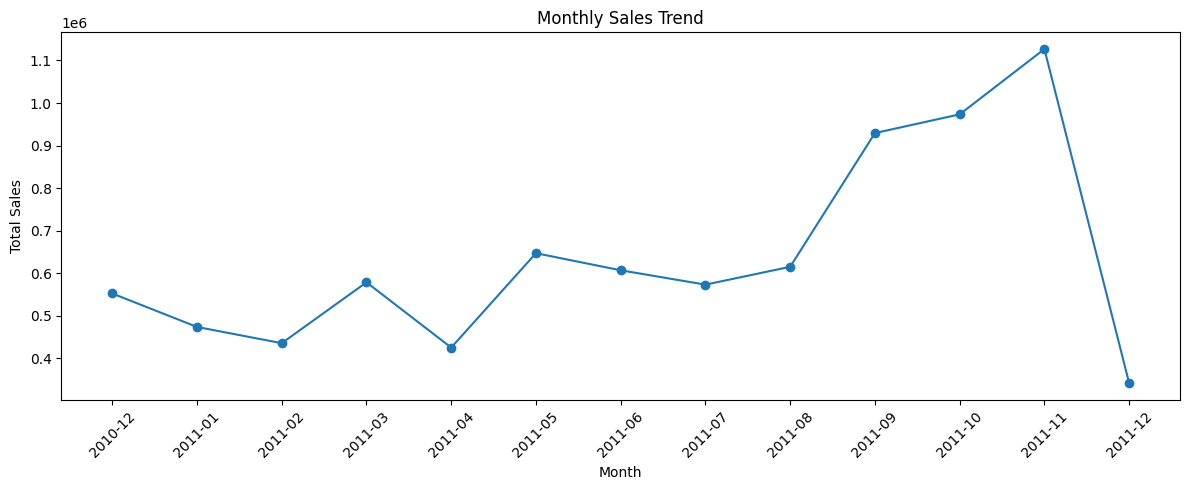

In [23]:
# Visualize monthly sales
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Calculate total spending by each customer
customer_spend = (
    df.groupby("CustomerID")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print("Top 10 High-Value Customers:")
print(customer_spend)

Top 10 High-Value Customers:
CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: TotalSales, dtype: float64


In [25]:
# Customer segmentation based on spending
customer_spend_all = df.groupby("CustomerID")["TotalSales"].sum()
customer_segments = pd.cut(
    customer_spend_all,
    bins=[0, 500, 2000, float("inf")],
    labels=["Low Value", "Medium Value", "High Value"]
)
print("Customer Segmentation:")
print(customer_segments.value_counts())

Customer Segmentation:
TotalSales
Low Value       1786
Medium Value    1665
High Value       871
Name: count, dtype: int64


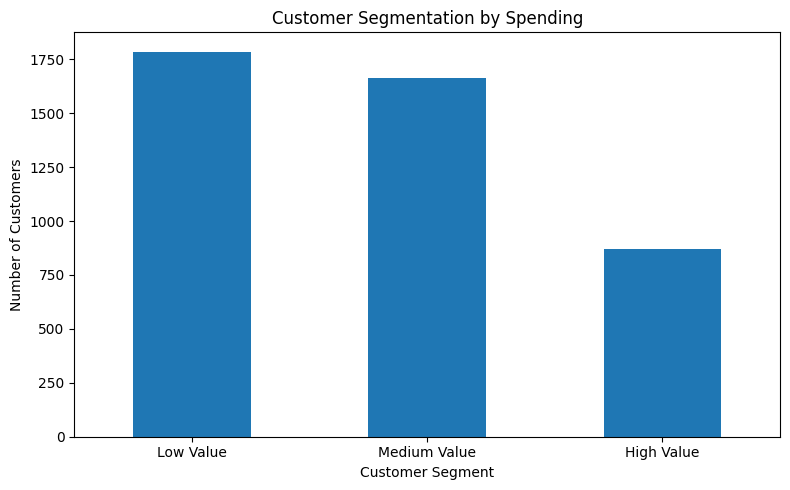

In [26]:
# Visualize customer segments
segment_counts = customer_segments.value_counts()
plt.figure(figsize=(8, 5))
segment_counts.plot(kind="bar")
plt.title("Customer Segmentation by Spending")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# Find top 10 products by revenue
top_revenue_products = (
    df.groupby("Description")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print("Top 10 Products by Revenue:")
print(top_revenue_products)

Top 10 Products by Revenue:
Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: TotalSales, dtype: float64


In [28]:
# Calculate revenue share of top 10 products
revenue_share = (top_revenue_products / total_revenue) * 100
print("Revenue Share of Top 10 Products:")
print(revenue_share)

Revenue Share of Top 10 Products:
Description
REGENCY CAKESTAND 3 TIER              1.601346
WHITE HANGING HEART T-LIGHT HOLDER    1.132664
JUMBO BAG RED RETROSPOT               1.003277
PARTY BUNTING                         0.816915
POSTAGE                               0.805823
ASSORTED COLOUR BIRD ORNAMENT         0.680459
RABBIT NIGHT LIGHT                    0.616570
CHILLI LIGHTS                         0.554633
PAPER CHAIN KIT 50'S CHRISTMAS        0.500377
PICNIC BASKET WICKER 60 PIECES        0.478582
Name: TotalSales, dtype: float64


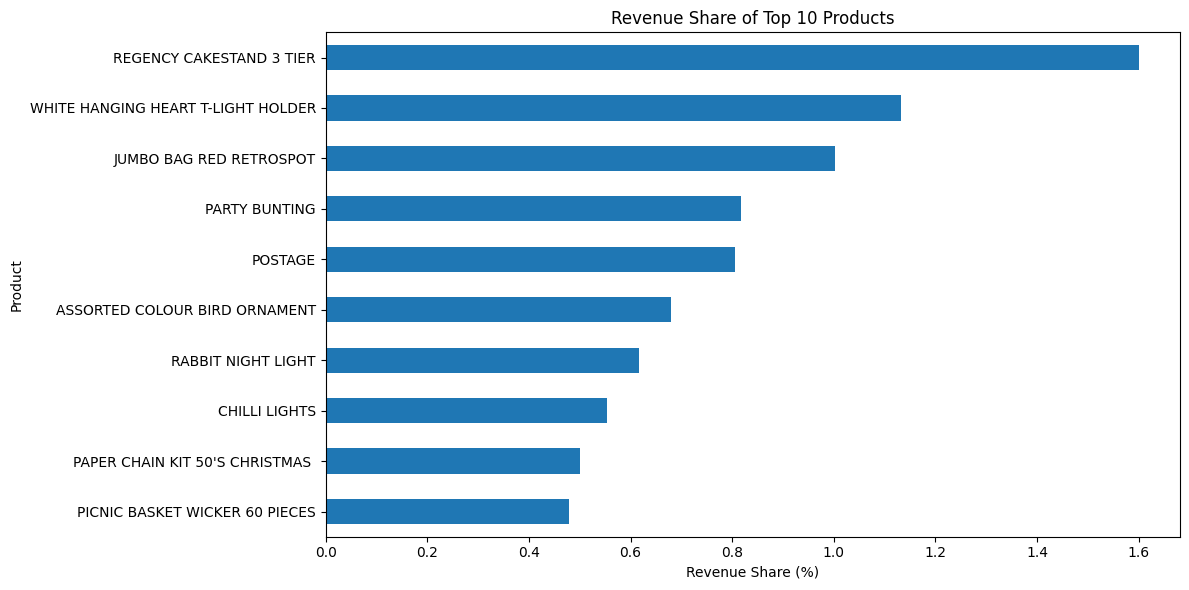

In [29]:
# Visualize revenue share of top 10 products
plt.figure(figsize=(12, 6))
revenue_share.sort_values().plot(kind="barh")
plt.title("Revenue Share of Top 10 Products")
plt.xlabel("Revenue Share (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [30]:
# Final Business Recommendations
print("FINAL BUSINESS RECOMMENDATIONS")
print("=" * 50)
print("1. Focus inventory on high-demand products such as WORLD WAR 2 GLIDERS ASSTD DESIGNS and JUMBO BAG RED RETROSPOT.")
print("2. REGENCY CAKESTAND 3 TIER generated the highest revenue among the analyzed products.")
print("3. Sales increased strongly during September to November 2011, suggesting strong seasonal demand.")
print("4. High-value customers should be targeted with loyalty programs and personalized offers.")
print("5. Medium-value customers can be encouraged to increase spending through promotions and cross-selling.")
print("6. Low-value customers can be targeted with discounts and product recommendations.")
print("7. Monitor inventory carefully before high-demand seasonal periods to avoid stock shortages.")
print("8. Use customer purchasing patterns to develop targeted marketing campaigns.")

FINAL BUSINESS RECOMMENDATIONS
1. Focus inventory on high-demand products such as WORLD WAR 2 GLIDERS ASSTD DESIGNS and JUMBO BAG RED RETROSPOT.
2. REGENCY CAKESTAND 3 TIER generated the highest revenue among the analyzed products.
3. Sales increased strongly during September to November 2011, suggesting strong seasonal demand.
4. High-value customers should be targeted with loyalty programs and personalized offers.
5. Medium-value customers can be encouraged to increase spending through promotions and cross-selling.
6. Low-value customers can be targeted with discounts and product recommendations.
7. Monitor inventory carefully before high-demand seasonal periods to avoid stock shortages.
8. Use customer purchasing patterns to develop targeted marketing campaigns.
